In [2]:
import pandas as pd 
import numpy as np 
from sklearn.preprocessing import StandardScaler  # pyright: ignore[reportMissingImports]
from sklearn.model_selection import train_test_split  # pyright: ignore[reportMissingImports]
from sklearn.tree import DecisionTreeClassifier  # pyright: ignore[reportMissingImports]
from sklearn.metrics import classification_report, confusion_matrix  # pyright: ignore[reportMissingImports]
import matplotlib.pyplot as plt
import seaborn as sns  # pyright: ignore[reportMissingModuleSource]
print("✓ Tüm kütüphaneler başarıyla yüklendi")

✓ Tüm kütüphaneler başarıyla yüklendi


## Müşteri Verisi DataFrame'i Oluşturma ##

>burada 1000 satırlık sahte bir DataFrame oluşturuyoru<< özellikler rastgele oluyor 

In [3]:
n_samples = 1000
data =pd.DataFrame({
    "KullaniciSuresi":np.random.randint(1, 72, n_samples),
    "AylikOdeme":np.random.normal(500, 15, n_samples),
    "ToplamGB":np.random.normal(100, 30, n_samples),
    "CagriMerkezi":np.random.randint(0, 10, n_samples),
    "Internet":np.random.choice(['Fiber', 'Dsl', 'Yok'], n_samples),
    "Telefon":np.random.choice(['Evet', 'Hayır'],n_samples),
    "TV":np.random.choice(['Evet', 'Hayır'], n_samples),
    "Kayip":np.random.choice([1, 0], n_samples, p=[0.8, 0.2])
})

## Veri Önİşleme

### kategorik değişkenleri dönüştürme

> Internet, TV, Telefon sütunlarını pd.get_dummies() ile ikili (0/1) sütunlara çevirir.

>Örnek: Internet için Internet_Fiber, Internet_Dsl, Internet_Yok gibi sütunlar oluşur.

### Sayısal değişkenleri standartlaştırma

>StandardScaler() ile KullaniciSuresi, AylikOdeme, ToplamGB, CagriMerkezi sütunlarını standartlaştırır.

>Her sütun ortalaması 0, standart sapması 1 olacak şekilde ölçeklenir.

*Amaç: Makine öğrenmesi modeline (DecisionTreeClassifier) uygun hale getirmek. Kategorik değişkenler sayısal forma, sayısal değişkenler aynı ölçeğe getirilir.*

In [4]:
def preprocess_data(df):
    df = pd.get_dummies(df, columns = ['Internet', 'TV', 'Telefon'], dtype = int) ## 1 ve 0 tablosuna dönüştürdü
    scaler = StandardScaler()
    numeric_colums = ['KullaniciSuresi', 'AylikOdeme', 'ToplamGB', 'CagriMerkezi']
    df[numeric_colums] = scaler.fit_transform(df[numeric_colums])
    return df

In [5]:
X = preprocess_data(data.drop('Kayip', axis = 1))
Y = data['Kayip']

> X = girdi özellikleri, 

> Y = tahmin edilecek hedef. 

> Bu ayrım, modelin X ile y'yi öğrenmesi için gereklidir.


*aşağıda yaptığımız*

> Veriyi böl → Model oluştur → Modeli eğit.

>Bu adımlardan sonra model, X_test üzerinde tahmin yapmak için kullanılabilir.

In [10]:
X_train, X_test, Y_train, Y_test = train_test_split(X,Y, test_size = 0.2)
model = DecisionTreeClassifier(max_depth = 5)
model.fit(X_train, Y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",5
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current 

*Aşağıdaki Bölümde* 

>Model tahmin yapar → Sonuçlar raporlanır.

>Bu sayede modelin ne kadar iyi çalıştığını görebilirsiniz.

In [7]:
Y_pred = model.predict(X_test)
print(classification_report(Y_test,Y_pred))

              precision    recall  f1-score   support

           0       1.00      0.02      0.04        44
           1       0.78      1.00      0.88       156

    accuracy                           0.79       200
   macro avg       0.89      0.51      0.46       200
weighted avg       0.83      0.79      0.70       200



### Confusion Matrix

> modelin doğru/yanlış tahminlerini görselleştirir. 

> hangi sınıflarda daha iyi/kötü olduğunu görmemizi sağlar

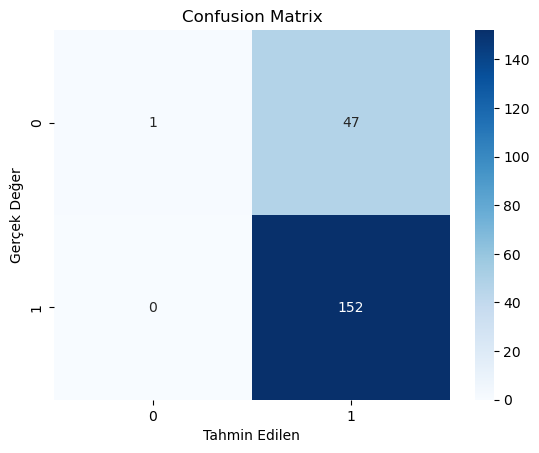

In [12]:
plt.figure()
cm = confusion_matrix(Y_test, Y_pred)
sns.heatmap(cm, annot = True, fmt = "d", cmap = "Blues")
plt.title("Confusion Matrix")
plt.xlabel("Tahmin Edilen")
plt.ylabel("Gerçek Değer")
plt.show()

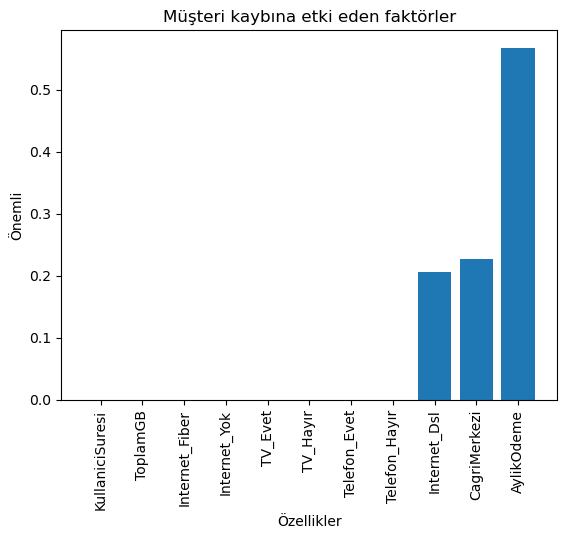

In [9]:
plt.figure()
ozellik_onemi = pd.DataFrame({
    "Özellik": X.columns,
    "Önemi": model.feature_importances_
})
ozellik_onemi = ozellik_onemi.sort_values("Önemi")
plt.bar(range(len(ozellik_onemi)),ozellik_onemi["Önemi"])
plt.xlabel("Özellikler")
plt.xticks(range(len(ozellik_onemi)),ozellik_onemi.Özellik,rotation =90)
plt.ylabel("Önemli")
plt.title("Müşteri kaybına etki eden faktörler")
plt.show()

> Hangi özelliklerin müşteri kaybını tahmin etmede daha etkili olduğunu gösterir. 

>Yüksek çubuk = daha önemli özellik.